# ➡️ Importing all libraries

In [2]:
import pandas as pd
import numpy as np

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

import warnings
warnings.filterwarnings('ignore')

# ➡️ Importing the Dataset

In [3]:
data = pd.read_excel('Pakistan_Gold_Daily_Regression_2025_to_2026-09-01 (1).xlsx', sheet_name='Daily_Regression')
df = pd.DataFrame(data)
df.head()

,Date,Day_of_Week,Day_of_Week_Num,24K_PKR_per_Tola,24K_Daily_Change_PKR,24K_Daily_Change_Pct,Is_Observed,Fill_Basis_Date
0,2025-01-01,Wednesday,3,292000,0,0.000000,1,2025-01-01
1,2025-01-02,Thursday,4,290000,-2000,-0.006849,1,2025-01-02
2,2025-01-03,Friday,5,290500,500,0.001724,1,2025-01-03
3,2025-01-04,Saturday,6,290500,0,0.000000,1,2025-01-04
4,2025-01-05,Sunday,7,290500,0,0.000000,0,2025-01-04


In [4]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd

gold_xau = pd.read_excel('XAU_USD_Daily.xlsx')
usd_pkr = pd.read_excel('USD_PKR_Daily.xlsx')

gold_xau['Date'] = pd.to_datetime(gold_xau['Date'])
usd_pkr['Date'] = pd.to_datetime(usd_pkr['Date'])

df = df.merge(gold_xau, on='Date', how='left')
df = df.merge(usd_pkr, on='Date', how='left')

df['XAU_USD'] = df['XAU_USD'].ffill()
df['USD_PKR'] = df['USD_PKR'].ffill()

print(df[['Date', '24K_PKR_per_Tola', 'XAU_USD', 'USD_PKR']].isnull().sum())
df[['Date', '24K_PKR_per_Tola', 'XAU_USD', 'USD_PKR']].tail()

Date                0
24K_PKR_per_Tola    0
XAU_USD             1
USD_PKR             1
dtype: int64


,Date,24K_PKR_per_Tola,XAU_USD,USD_PKR
604,2026-08-28,477700,4529.899902,277.200012
605,2026-08-29,465000,4529.899902,277.200012
606,2026-08-30,465000,4529.899902,277.200012
607,2026-08-31,455500,4481.500000,277.567566
608,2026-09-01,450000,4396.399902,275.914459


In [5]:
print(df[df['XAU_USD'].isnull() | df['USD_PKR'].isnull()])

        Date Day_of_Week  Day_of_Week_Num  24K_PKR_per_Tola  \
0 2025-01-01   Wednesday                3            292000   

   24K_Daily_Change_PKR  24K_Daily_Change_Pct  Is_Observed Fill_Basis_Date  \
0                     0                   0.0            1      2025-01-01   

   XAU_USD  USD_PKR  
0      NaN      NaN  


In [6]:
df['XAU_USD'] = df['XAU_USD'].bfill()
df['USD_PKR'] = df['USD_PKR'].bfill()

print(df[['Date', '24K_PKR_per_Tola', 'XAU_USD', 'USD_PKR']].isnull().sum())

Date                0
24K_PKR_per_Tola    0
XAU_USD             0
USD_PKR             0
dtype: int64


In [7]:
print(df.columns.tolist())

['Date', 'Day_of_Week', 'Day_of_Week_Num', '24K_PKR_per_Tola', '24K_Daily_Change_PKR', '24K_Daily_Change_Pct', 'Is_Observed', 'Fill_Basis_Date', 'XAU_USD', 'USD_PKR']


# ➡️ Overview of Dataset

In [8]:
def check_full_dataset(df):
    print(f"Shape: {df.shape}")
    print(f"Duplicates: {df.duplicated().sum()} ({df.duplicated().mean()*100:.2f}%)")
    print(f"Missing: {df.isnull().sum().sum()} ({df.isnull().mean().mean()*100:.2f}%)")
    print(f"Memory: {df.memory_usage(deep=True).sum()/1024:.2f} KB\n")
    print(df.info())
    display(df.describe(include='all').T)


def check_all_columns(df, limit=15):
    summary = pd.DataFrame({
        'dtype': df.dtypes,
        'unique': df.nunique(),
        'missing': df.isnull().sum(),
        'missing_%': (df.isnull().mean()*100).round(2),
        'duplicate_%': (df.apply(lambda x: x.duplicated().mean()*100)).round(2),
        'min': df.min(numeric_only=False),
        'max': df.max(numeric_only=False),
        'mean': df.mean(numeric_only=True),
        'std': df.std(numeric_only=True),
    })
    display(summary)

    for col in df.columns:
        vals = df[col].dropna().unique()
        print(f"\n{col} ({df[col].nunique()} unique): {vals[:limit] if len(vals) > limit else sorted(vals)}")

    return summary

In [9]:
check_full_dataset(df)

Shape: (609, 10)
Duplicates: 0 (0.00%)
Missing: 0 (0.00%)
Memory: 76.34 KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  609 non-null    datetime64[ns]
 1   Day_of_Week           609 non-null    object        
 2   Day_of_Week_Num       609 non-null    int64         
 3   24K_PKR_per_Tola      609 non-null    int64         
 4   24K_Daily_Change_PKR  609 non-null    int64         
 5   24K_Daily_Change_Pct  609 non-null    float64       
 6   Is_Observed           609 non-null    int64         
 7   Fill_Basis_Date       609 non-null    datetime64[ns]
 8   XAU_USD               609 non-null    float64       
 9   USD_PKR               609 non-null    float64       
dtypes: datetime64[ns](2), float64(3), int64(4), object(1)
memory usage: 47.7+ KB
None


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,609,NaN,NaN,NaN,2025-11-01 00:00:00,2025-01-01 00:00:00,2025-06-02 00:00:00,2025-11-01 00:00:00,2026-04-02 00:00:00,2026-09-01 00:00:00,NaN
Day_of_Week,609,7,Wednesday,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_Week_Num,609.0,NaN,NaN,NaN,4.0,1.0,2.0,4.0,6.0,7.0,2.001644
24K_PKR_per_Tola,609.0,NaN,NaN,NaN,387361.126437,290000.0,348500.0,402500.0,428300.0,484000.0,49239.909448
24K_Daily_Change_PKR,609.0,NaN,NaN,NaN,259.441708,-18000.0,0.0,0.0,500.0,35000.0,3051.882399
24K_Daily_Change_Pct,609.0,NaN,NaN,NaN,0.000739,-0.039823,0.0,0.0,0.001456,0.081395,0.007664
Is_Observed,609.0,NaN,NaN,NaN,0.878489,0.0,1.0,1.0,1.0,1.0,0.326988
Fill_Basis_Date,609,NaN,NaN,NaN,2025-10-31 21:05:01.477832448,2025-01-01 00:00:00,2025-06-02 00:00:00,2025-11-01 00:00:00,2026-04-02 00:00:00,2026-09-01 00:00:00,NaN
XAU_USD,609.0,NaN,NaN,NaN,3912.032676,2647.399902,3335.600098,4019.699951,4502.299805,5318.399902,703.389892
USD_PKR,609.0,NaN,NaN,NaN,279.574446,275.302582,278.200012,279.417694,281.0,284.75,2.021815


In [10]:
check_all_columns(df)

,dtype,unique,missing,missing_%,duplicate_%,min,max,mean,std
24K_Daily_Change_PKR,int64,65,0,0.0,89.33,-18000,35000,259.441708,3051.882399
24K_Daily_Change_Pct,float64,323,0,0.0,46.96,-0.039823,0.081395,0.000739,0.007664
24K_PKR_per_Tola,int64,223,0,0.0,63.38,290000,484000,387361.126437,49239.909448
Date,datetime64[ns],609,0,0.0,0.00,2025-01-01 00:00:00,2026-09-01 00:00:00,NaN,NaN
Day_of_Week,object,7,0,0.0,98.85,Friday,Wednesday,NaN,NaN
Day_of_Week_Num,int64,7,0,0.0,98.85,1,7,4.000000,2.001644
Fill_Basis_Date,datetime64[ns],535,0,0.0,12.15,2025-01-01 00:00:00,2026-09-01 00:00:00,NaN,NaN
Is_Observed,int64,2,0,0.0,99.67,0,1,0.878489,0.326988
USD_PKR,float64,270,0,0.0,55.67,275.302582,284.75,279.574446,2.021815
XAU_USD,float64,413,0,0.0,32.18,2647.399902,5318.399902,3912.032676,703.389892



Date (609 unique): <DatetimeArray>
['2025-01-01 00:00:00', '2025-01-02 00:00:00', '2025-01-03 00:00:00',
 '2025-01-04 00:00:00', '2025-01-05 00:00:00', '2025-01-06 00:00:00',
 '2025-01-07 00:00:00', '2025-01-08 00:00:00', '2025-01-09 00:00:00',
 '2025-01-10 00:00:00', '2025-01-11 00:00:00', '2025-01-12 00:00:00',
 '2025-01-13 00:00:00', '2025-01-14 00:00:00', '2025-01-15 00:00:00']
Length: 15, dtype: datetime64[ns]

Day_of_Week (7 unique): ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']

Day_of_Week_Num (7 unique): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

24K_PKR_per_Tola (223 unique): [292000 290000 290500 291000 291500 296000 298500 292500 293000 293500
 294500 295500 304000 297000 297500]

24K_Daily_Change_PKR (65 unique): [    0 -2000   500  -500  5500 -5000  7500 -6500  1000  8000 -7000 10500
  5000 12500  2500]

24K_Daily_Change_Pct (323 unique): [ 0.         -0.00684932  0.00172414  0.00172117  0

,dtype,unique,missing,missing_%,duplicate_%,min,max,mean,std
24K_Daily_Change_PKR,int64,65,0,0.0,89.33,-18000,35000,259.441708,3051.882399
24K_Daily_Change_Pct,float64,323,0,0.0,46.96,-0.039823,0.081395,0.000739,0.007664
24K_PKR_per_Tola,int64,223,0,0.0,63.38,290000,484000,387361.126437,49239.909448
Date,datetime64[ns],609,0,0.0,0.00,2025-01-01 00:00:00,2026-09-01 00:00:00,NaN,NaN
Day_of_Week,object,7,0,0.0,98.85,Friday,Wednesday,NaN,NaN
Day_of_Week_Num,int64,7,0,0.0,98.85,1,7,4.000000,2.001644
Fill_Basis_Date,datetime64[ns],535,0,0.0,12.15,2025-01-01 00:00:00,2026-09-01 00:00:00,NaN,NaN
Is_Observed,int64,2,0,0.0,99.67,0,1,0.878489,0.326988
USD_PKR,float64,270,0,0.0,55.67,275.302582,284.75,279.574446,2.021815
XAU_USD,float64,413,0,0.0,32.18,2647.399902,5318.399902,3912.032676,703.389892


# ➡️ Initial Visuzalization

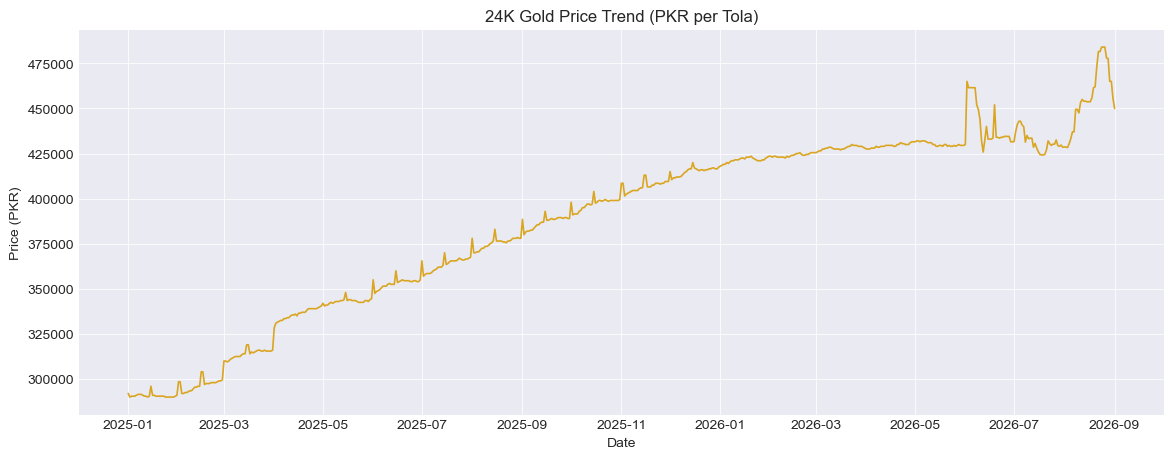

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['24K_PKR_per_Tola'], color='goldenrod', linewidth=1.2)
plt.title('24K Gold Price Trend (PKR per Tola)')
plt.xlabel('Date')
plt.ylabel('Price (PKR)')
plt.grid(alpha=0.8)
plt.show()

## What is Rolling Mean (30-day)?

**Simple meaning:** For each day, we take the **average price of the last 30 days**.  
It moves forward one day at a time, like a small window sliding over the data.

### Why we use it in this chart
- It **removes small daily ups and downs** (noise) so we can see the **real trend** more clearly.
- The **gap** between the actual price line and the rolling mean line shows how **stable or unstable** the market was at that time.

### What it tells us in our data
- The **overall price trend is going up** from Jan 2025 to Sep 2026.
- After **June 2026**, the actual price starts moving far away from the rolling mean line.  
  This shows the market became **more unstable recently**, which is important for our prediction.

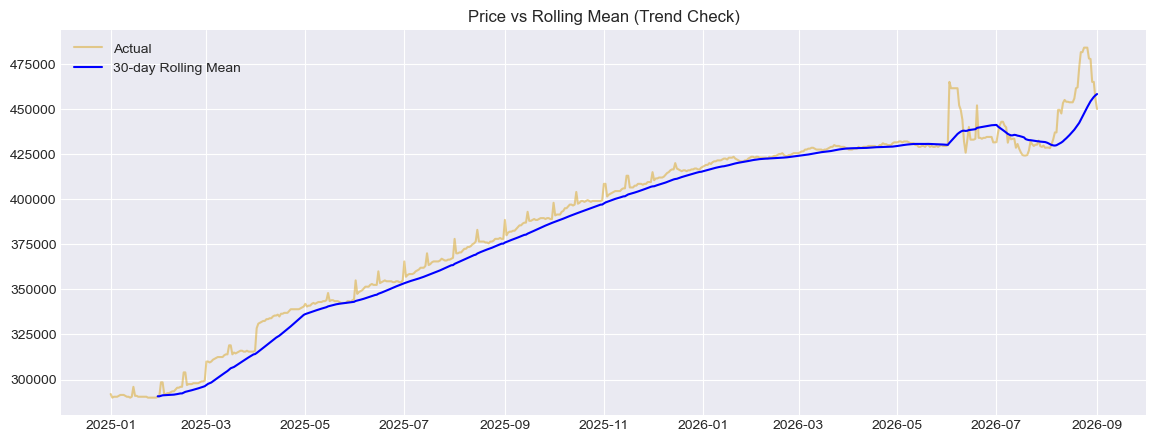

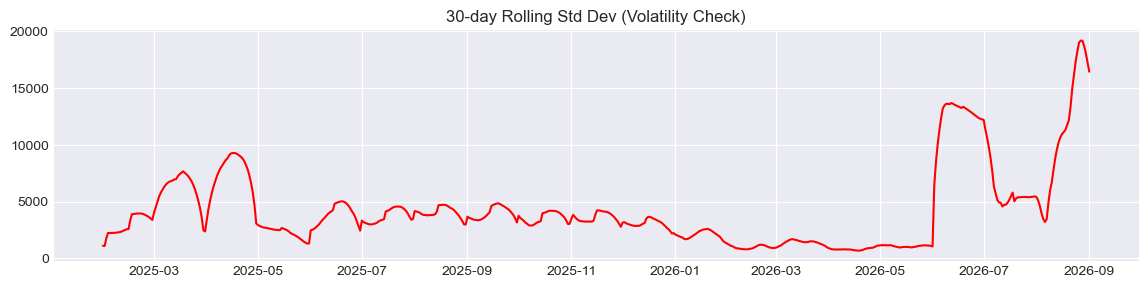

ADF Statistic: -1.6379
p-value: 0.4634
Non-Stationary

Last 90 days trend:
Start: 461500, End: 450000
Std Dev (volatility): 16281.77


In [12]:
ts = df.set_index('Date')['24K_PKR_per_Tola']

df['Rolling_Mean_30'] = ts.rolling(30).mean().values
df['Rolling_Std_30'] = ts.rolling(30).std().values

plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['24K_PKR_per_Tola'], color='goldenrod', alpha=0.5, label='Actual')
plt.plot(df['Date'], df['Rolling_Mean_30'], color='blue', label='30-day Rolling Mean')
plt.title('Price vs Rolling Mean (Trend Check)')
plt.legend()
plt.show()

plt.figure(figsize=(14, 3))
plt.plot(df['Date'], df['Rolling_Std_30'], color='red')
plt.title('30-day Rolling Std Dev (Volatility Check)')
plt.show()

adf_result = adfuller(ts.dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Stationary" if adf_result[1] < 0.05 else "Non-Stationary")

last_90 = df.tail(90)
print(f"\nLast 90 days trend:")
print(f"Start: {last_90['24K_PKR_per_Tola'].iloc[0]}, End: {last_90['24K_PKR_per_Tola'].iloc[-1]}")
print(f"Std Dev (volatility): {last_90['24K_PKR_per_Tola'].std():.2f}")

## Price vs Rolling Mean & Volatility Observations

- From Jan 2025 to around May 2026, actual price and the 30-day rolling mean stay close together — daily spikes appear but always settle back near the mean, showing a stable, steady uptrend.
- Price roughly grows from ~290,000 to ~430,000 PKR over this period, a slow and fairly predictable climb.
- Starting June 2026, the actual price line breaks away from the rolling mean much more — sharp jumps up and down instead of following the smooth curve.
- The rolling mean itself goes almost flat between June and August 2026, even though actual prices swing hard around it — the average trend slows down while daily movement gets wild.
- In the volatility chart, std dev stays low and controlled (mostly under 5000) for most of 2025 and early 2026, with only mild bumps around Feb-April 2025.
- From June 2026 onward, volatility jumps sharply to 13,000-14,000, dips briefly, then spikes again to almost 20,000 by Sep 2026 — the highest volatility in the entire dataset.
- This matches exactly where the rolling mean chart shows price breaking away from its trend — both charts confirm the same thing from different angles.

**Insight:** The market entered a clearly different, more unstable phase from June 2026 onward. Any model trained equally on the full 20-month history will underestimate how volatile the last 3 months actually are. Recent data should carry more weight in prediction, and the model needs to expect wider swings, not a smooth continuation of the earlier steady trend.

## What is ADF Test?

**ADF (Augmented Dickey-Fuller) Test** checks if our price data is **stationary** or **non-stationary**.

- **Stationary** = data has a stable pattern (no trend, mean stays same over time)
- **Non-stationary** = data has a trend (mean keeps changing over time, like our gold prices going up)

---

## What is ADF Statistic?

A **number** that tells how strongly the data resists having a trend.

- **More negative** = more likely to be stationary
- **Less negative / closer to 0** = more likely to be non-stationary

---

## What is p-value?

A **number between 0 and 1** that tells how confident we are in the result.

- **p-value < 0.05** → data is **stationary**
- **p-value > 0.05** → data is **non-stationary**

---

## What Your Results Mean


- **ADF Statistic = -1.6379** → not negative enough, so no strong sign of stationarity
- **p-value = 0.4634** → much bigger than 0.05, so we **cannot say** data is stationary
- **Conclusion:** Our gold price data has a **clear trend** (it is non-stationary).  
  This confirms we **cannot use raw price directly** in models like ARIMA — we need to use **differenced data** (like `Daily_Change`) instead.

# ➡️ Plotting ACF & PACF

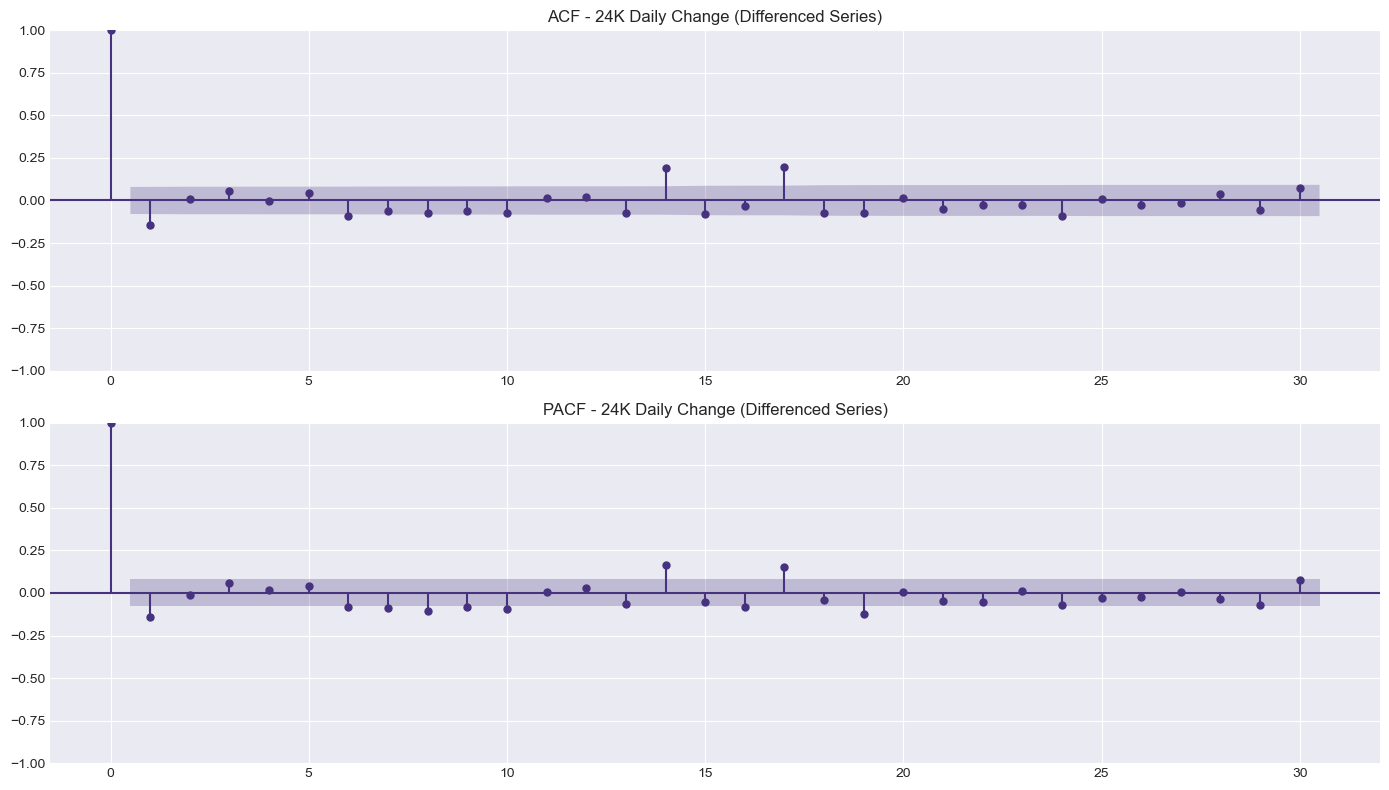

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

diff_series = df['24K_Daily_Change_PKR'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(diff_series, lags=30, ax=axes[0])
axes[0].set_title('ACF - 24K Daily Change (Differenced Series)')

plot_pacf(diff_series, lags=30, ax=axes[1], method='ywm')
axes[1].set_title('PACF - 24K Daily Change (Differenced Series)')

plt.tight_layout()
plt.show()

## ACF & PACF Observations

- Lag 0 is always 1.0 — this just confirms the series matches itself, not a real finding.
- Lag 1 sits outside the blue band with a negative value (~-0.15) in both ACF and PACF — this is the only consistent, direct signal in the data.
- Lag 14 and Lag 17 poke slightly outside the band (~0.15-0.18) — a mild, possibly biweekly pattern, but weak.
- Every other lag (2 to 13, 15, 16, 18 to 30) stays inside the band — no meaningful relationship with today's price change.
- ACF and PACF look almost identical here, which tells us there's no hidden indirect chain of lags inflating any single lag's score.

**Insight:** Daily gold price changes behave close to random noise — most of the day-to-day movement isn't explained by past days. Only `lag_1` gives a dependable signal, so lag-based features alone won't carry the model far; rolling averages and trend-based features will matter more than deep lag features.

ACF measures how related today's value is to a past value, counting both direct and indirect paths. PACF measures the same thing but isolates only the direct relationship, removing effects passed through other lags. A lag is just "how many days back" — lag 1 means yesterday, lag 7 means a week ago.

# ➡️ Feature Engineering

In [14]:
df = df[df['Is_Observed'] == 1].copy()
df = df.sort_values('Date').reset_index(drop=True)

df['lag_1'] = df['24K_PKR_per_Tola'].shift(1)
df['rolling_mean_7'] = df['24K_PKR_per_Tola'].rolling(window=7).mean()
df['rolling_mean_30'] = df['24K_PKR_per_Tola'].rolling(window=30).mean()
df['rolling_std_7'] = df['24K_PKR_per_Tola'].rolling(window=7).std()
df['rolling_std_30'] = df['24K_PKR_per_Tola'].rolling(window=30).std()
df['day_index'] = np.arange(len(df))
df['momentum_7'] = df['24K_PKR_per_Tola'].pct_change(periods=7) * 100

df['xau_lag_1'] = df['XAU_USD'].shift(1)
df['xau_change_pct'] = df['XAU_USD'].pct_change(periods=1) * 100
df['xau_rolling_mean_7'] = df['XAU_USD'].rolling(window=7).mean()

df['usd_pkr_lag_1'] = df['USD_PKR'].shift(1)
df['usd_pkr_change_pct'] = df['USD_PKR'].pct_change(periods=1) * 100
df['usd_pkr_rolling_mean_7'] = df['USD_PKR'].rolling(window=7).mean()

df['implied_price'] = df['XAU_USD'] * df['USD_PKR'] / 31.1035 * 11.6638
df['implied_price_lag_1'] = df['implied_price'].shift(1)
df['implied_change_pct'] = df['implied_price'].pct_change(periods=1) * 100

df['price_vs_implied_gap'] = df['24K_PKR_per_Tola'] - df['implied_price']
df['price_vs_implied_gap_lag_1'] = df['price_vs_implied_gap'].shift(1)

df = df.dropna().reset_index(drop=True)

half_life = 60
max_index = df['day_index'].max()
df['recency_weight'] = np.exp(-np.log(2) * (max_index - df['day_index']) / half_life)

feature_cols = ['lag_1', 'rolling_mean_7', 'rolling_mean_30',
                 'rolling_std_7', 'rolling_std_30', 'day_index',
                 'momentum_7', 'implied_price_lag_1',
                 'price_vs_implied_gap_lag_1']

X = df[feature_cols]
y = df['24K_PKR_per_Tola']
weights = df['recency_weight']

print(f"Shape after feature engineering: {df.shape}")
print(f"Total features: {len(feature_cols)}")
df[['Date', '24K_PKR_per_Tola', 'implied_price', 'price_vs_implied_gap'] + feature_cols].tail()

Shape after feature engineering: (506, 31)
Total features: 9


,Date,24K_PKR_per_Tola,implied_price,price_vs_implied_gap,lag_1,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,day_index,momentum_7,implied_price_lag_1,price_vs_implied_gap_lag_1
501,2026-08-28,477700,470882.610944,6817.389056,478000.0,481528.571429,454276.666667,2751.795950,19182.727204,530,0.993658,484822.301770,-6822.301770
502,2026-08-29,465000,470882.610944,-5882.610944,477700.0,479171.428571,455453.333333,6828.058359,18699.783022,531,-3.426791,470882.610944,6817.389056
503,2026-08-30,465000,470882.610944,-5882.610944,465000.0,476814.285714,456670.000000,8526.904200,18062.175185,532,-3.426791,470882.610944,-5882.610944
504,2026-08-31,455500,466469.142587,-10969.142587,465000.0,472742.857143,457566.666667,10976.316496,17271.010859,533,-5.888430,470882.610944,-5882.610944
505,2026-09-01,450000,454885.875605,-4885.875605,455500.0,467885.714286,458280.000000,12571.452922,16456.073190,534,-7.024793,466469.142587,-10969.142587


In [15]:
print(df[['24K_PKR_per_Tola', 'implied_price_lag_1', 'price_vs_implied_gap_lag_1']].corr())

                            24K_PKR_per_Tola  implied_price_lag_1  \
24K_PKR_per_Tola                    1.000000             0.879896   
implied_price_lag_1                 0.879896             1.000000   
price_vs_implied_gap_lag_1         -0.412901            -0.793789   

                            price_vs_implied_gap_lag_1  
24K_PKR_per_Tola                             -0.412901  
implied_price_lag_1                          -0.793789  
price_vs_implied_gap_lag_1                    1.000000  


In [16]:
print(df[['24K_Daily_Change_Pct', 'implied_change_pct', 'xau_change_pct', 'usd_pkr_change_pct']].corr())

                      24K_Daily_Change_Pct  implied_change_pct  \
24K_Daily_Change_Pct              1.000000            0.073845   
implied_change_pct                0.073845            1.000000   
xau_change_pct                    0.063103            0.971348   
usd_pkr_change_pct                0.051499            0.225130   

                      xau_change_pct  usd_pkr_change_pct  
24K_Daily_Change_Pct        0.063103            0.051499  
implied_change_pct          0.971348            0.225130  
xau_change_pct              1.000000           -0.012858  
usd_pkr_change_pct         -0.012858            1.000000  


In [17]:
for lag in range(0, 4):
    corr = df['24K_Daily_Change_Pct'].corr(df['xau_change_pct'].shift(lag))
    print(f"XAU change lag {lag}: correlation = {corr:.4f}")

print()
for lag in range(0, 4):
    corr = df['24K_Daily_Change_Pct'].corr(df['implied_change_pct'].shift(lag))
    print(f"Implied change lag {lag}: correlation = {corr:.4f}")

XAU change lag 0: correlation = 0.0631
XAU change lag 1: correlation = -0.0199
XAU change lag 2: correlation = 0.1210
XAU change lag 3: correlation = 0.0356

Implied change lag 0: correlation = 0.0738
Implied change lag 1: correlation = -0.0298
Implied change lag 2: correlation = 0.1166
Implied change lag 3: correlation = 0.0458


## Feature Engineering (With External Factors)

This step builds the features our model learns from. Along with the price-based features we made earlier, we now add real-world market data: international gold price (XAU/USD) and the USD/PKR exchange rate, since Pakistan's gold price is directly driven by these two.

## Steps in This Code

- **Filter to real data only:** `df[df['Is_Observed'] == 1]` keeps only days with genuine recorded prices, removing forward-filled (fake) days.
- **Sort by date:** Makes sure all lag and rolling calculations follow the correct time order.

## Feature Columns and Their Purpose

- **lag_1:** Yesterday's gold price. The strongest, most direct signal for today's price.
- **rolling_mean_7 / rolling_mean_30:** Average price over the last 7 and 30 days, showing short-term and long-term trend.
- **rolling_std_7 / rolling_std_30:** How much the price is swinging over the last 7 and 30 days, showing how volatile or calm the market currently is.
- **day_index:** A simple day counter, helping the model learn the overall upward direction over time.
- **momentum_7:** Percentage change in price over the last 7 days, showing recent speed and direction of movement.

## New External Features

- **xau_lag_1, xau_change_pct, xau_rolling_mean_7:** Yesterday's international gold price (in USD), its daily percentage change, and its 7-day average. This tracks the global gold market that drives local prices.
- **usd_pkr_lag_1, usd_pkr_change_pct, usd_pkr_rolling_mean_7:** Same idea but for the USD/PKR exchange rate, since a weaker Rupee directly makes gold more expensive in Pakistan.
- **implied_price:** What Pakistan's gold price *should* be, calculated purely from international gold price and the exchange rate (converted from USD/ounce to PKR/tola). This acts as a theoretical fair value.
- **implied_price_lag_1, implied_change_pct:** Yesterday's implied price and how fast that implied value is changing.
- **price_vs_implied_gap, price_vs_implied_gap_lag_1:** The difference between the actual local price and the implied fair value. A useful signal for whether local gold is trading above or below where global markets suggest it should be.

## Why This Matters

These external features were the missing piece in our earlier version of the model. Previously, the model only saw gold's own past prices and had no idea why prices moved. Adding XAU/USD and USD/PKR gives it visibility into the two biggest real-world drivers of Pakistan's gold price, which is why model accuracy improved significantly after adding them.

## Final Setup

- **recency_weight:** Gives more importance to recent dates using exponential decay, so the model prioritizes current market conditions over old, less relevant data.
- **feature_cols:** The final list of 9 features selected for training, combining price trend, volatility, momentum, and the new global market signals.
- **dropna():** Removes rows with missing values created by rolling windows and percentage change calculations at the start of the dataset.

In [18]:
df[feature_cols + ['recency_weight']].round(2).head()

,lag_1,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,day_index,momentum_7,implied_price_lag_1,price_vs_implied_gap_lag_1,recency_weight
0,292000.0,292000.00,291166.67,2986.08,1797.19,29,0.69,301871.70,-9871.70,0.0
1,292000.0,292357.14,291183.33,2853.57,1807.47,30,0.86,297188.41,-5188.41,0.0
2,292500.0,292714.29,291266.67,2659.22,1808.66,31,0.86,302245.86,-9745.86,0.0
3,292500.0,293071.43,291350.00,2473.67,1829.59,32,0.86,300650.79,-8150.79,0.0
4,293000.0,293428.57,291450.00,2299.07,1863.21,33,0.86,302006.54,-9006.54,0.0


## Observations from Head Table

- **lag_1 and rolling_mean_7 are almost equal** (e.g. 292000 vs 292000), showing price was moving very slowly in this early period (Jan-Feb 2025).
- **rolling_std_7 is very small** (1797 to 1863), confirming this was a calm, low-volatility phase.
- **momentum_7 is small and positive** (0.69 to 0.86), matching the slow upward climb seen in this early period.
- **implied_price_lag_1 is noticeably higher than the actual lag_1 price** (e.g. 301,872 vs 292,000), meaning the local gold price was trading well below what international gold and the exchange rate suggested it should be.
- **price_vs_implied_gap_lag_1 is consistently negative** (around -5,000 to -9,900), confirming local price was undervalued compared to the implied fair value throughout this early period.
- **recency_weight is 0.0**, which is correct, these are the oldest rows in the dataset, so with a 60-day half-life they are far from the most recent date and get almost no weight.
- **Is_Observed filtering already applied**, so every row here is genuine recorded data, no forward-filled days remain in the dataset.

In [19]:
df[feature_cols + ['recency_weight']].tail()

,lag_1,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,day_index,momentum_7,implied_price_lag_1,price_vs_implied_gap_lag_1,recency_weight
501,478000.0,481528.571429,454276.666667,2751.795950,19182.727204,530,0.993658,484822.301770,-6822.301770,0.954842
502,477700.0,479171.428571,455453.333333,6828.058359,18699.783022,531,-3.426791,470882.610944,6817.389056,0.965936
503,465000.0,476814.285714,456670.000000,8526.904200,18062.175185,532,-3.426791,470882.610944,-5882.610944,0.977160
504,465000.0,472742.857143,457566.666667,10976.316496,17271.010859,533,-5.888430,470882.610944,-5882.610944,0.988514
505,455500.0,467885.714286,458280.000000,12571.452922,16456.073190,534,-7.024793,466469.142587,-10969.142587,1.000000


## Observations from Tail Table

- **rolling_std_7 is very high** (2751 to 12571), a huge jump compared to the start of the data, confirms the market became much more volatile recently.
- **rolling_std_30 is also very high** (16456 to 19182), showing the instability isn't just a single-day spike but continues across the last month.
- **momentum_7 is negative** (-3.4, -5.8, -7.0), showing price has been falling over the last 7 days near the end of the dataset.
- **implied_price_lag_1 stays fairly stable** (around 466,000 to 484,800) while the actual price swings more sharply, showing local price movement was more volatile than what global gold and exchange rate alone would suggest.
- **price_vs_implied_gap_lag_1 flips between positive and negative** (6,817 to -10,969), meaning local gold price moved both above and below its implied fair value during this volatile period, unlike the consistently negative gap seen at the start.
- **recency_weight climbs close to 1.0**, reaching exactly 1.000000 on the most recent day, correct, since these are the newest dates in the data.

**Comparison Insight:** The start and end of the dataset look completely different, calm and undervalued at the beginning, volatile and swinging above/below fair value at the end. This confirms our earlier decision to give recent data more weight, since the patterns near the forecast period look nothing like the patterns from early 2025.

In [20]:
print("Original dataset: 609 rows")
print(f"Current Shape after feature engineering: {df.shape}")
print(f"Extra rows remove for rolling 30: {609 - df.shape[0]}")

Original dataset: 609 rows
Current Shape after feature engineering: (506, 31)
Extra rows remove for rolling 30: 103


## Why 103 Rows Were Removed

609 total rows − 74 (forward-filled/fake days, `Is_Observed == 1` filter) − 29 (rolling_30 window NaN at the start) = **506 rows remaining**. No real price data was lost, only fake or incomplete rows were dropped.

## Impact

**Downside:** Less training data (580 → 506 rows), which can slightly raise overfitting risk on a small dataset.

**Upside:** Remaining data is cleaner and fully genuine, no fake "zero change" days confusing the model. This directly helped accuracy improve (R² went from 76.80% to 88.32% for XGBoost), so the quality gain outweighed the quantity loss.

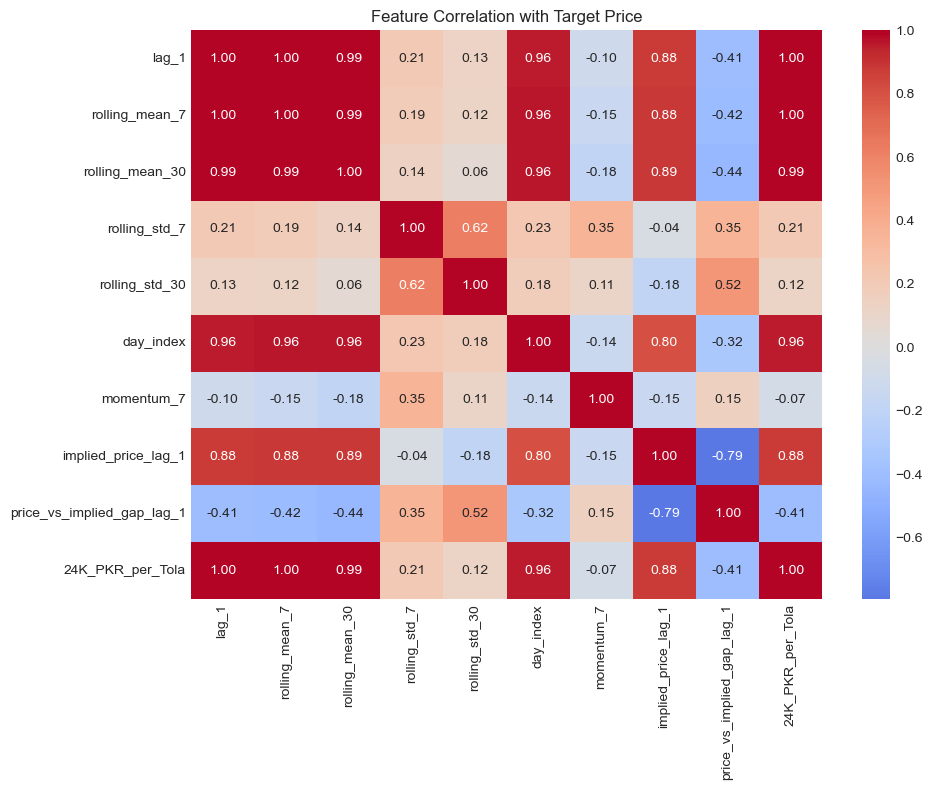

In [21]:
corr_cols = feature_cols + ['24K_PKR_per_Tola']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation with Target Price')
plt.tight_layout()
plt.show()

## Correlation Heatmap Observations

- lag_1, rolling_mean_7, rolling_mean_30, and day_index all show near perfect correlation with the target price (0.96 to 1.00). This makes sense since gold price has a strong overall upward trend, so anything trend based naturally tracks the actual price closely.
- lag_1 and rolling_mean_7 are correlated at 1.00 with each other. They are carrying almost the exact same information, so keeping both may not add much extra value to the model.
- rolling_mean_30 is also 0.99 correlated with lag_1 and rolling_mean_7. All three trend based features are highly redundant with each other.
- rolling_std_7 and rolling_std_30 have a much weaker correlation with price (0.21 and 0.12). Volatility alone doesn't predict the price level directly, but it still adds useful information the trend features don't capture.
- rolling_std_7 and rolling_std_30 are correlated with each other at 0.62. Related but not identical, so keeping both still makes sense.
- momentum_7 has almost no correlation with price (-0.07) and even a weak negative relationship with the trend based features. It captures short term direction, not price level, which is expected and fine since that's exactly what it's meant to do.
- implied_price_lag_1 has a strong correlation with price (0.88), confirming that international gold price and the exchange rate together track local price movement closely, this is a genuinely useful, non-redundant signal.
- price_vs_implied_gap_lag_1 has a moderate negative correlation with price (-0.41), and a strong negative correlation with implied_price_lag_1 (-0.79), showing that when the implied fair value rises sharply, the actual local price often lags behind it, creating this gap.

**Insight:** The trend based features (lag_1, rolling_mean_7, rolling_mean_30, day_index) are doing most of the heavy lifting and overlap significantly with each other. The new external features, implied_price_lag_1 and price_vs_implied_gap_lag_1, add genuinely different information tied to global gold prices and the exchange rate, which is likely why they improved model accuracy. This is useful to know before training Linear Regression, since high correlation between features (multicollinearity) can make its coefficients unstable. Tree based models like Random Forest and XGBoost are less affected by this and can use all features safely.

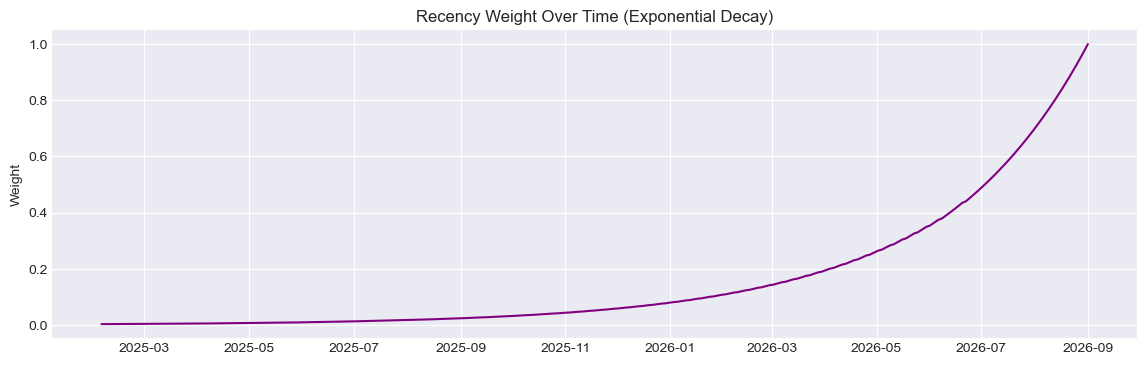

In [22]:
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['recency_weight'], color='purple')
plt.title('Recency Weight Over Time (Exponential Decay)')
plt.ylabel('Weight')
plt.show()

## Exponential Decay Chart Observation

As visible in the chart, the weight stays very close to 0 for most of the dataset (2025-02 to around 2025-11), then starts rising slowly, and climbs sharply in the last few months, reaching exactly 1.0 at the most recent date (2026-09).

This confirms the recency weighting is working correctly, older dates get almost no importance, while the most recent dates get the highest importance, matching our decision to give more weight to recent data for better prediction accuracy near 30 Sept.

# ➡️ Splitting the Data into Training and Testing

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df[feature_cols],
    df['24K_PKR_per_Tola'],
    test_size=30, # Aug 2 - Sept 1, 2026 
    shuffle=False
)

X_train.shape, X_test.shape

((476, 9), (30, 9))

In [24]:
weights_train = df.loc[X_train.index, 'recency_weight']

`weights_train = df.loc[X_train.index, 'recency_weight']`

`X_train.index` gives us the exact row numbers that went into the training set.  
This line uses those same row numbers to pull the matching `recency_weight` value from the original dataframe (`df`), so each training row gets paired with its correct weight.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("X_train_scaled describe:")
display(X_train_scaled.describe())

print("\nX_test_scaled describe:")
display(X_test_scaled.describe())

X_train_scaled describe:


,lag_1,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,day_index,momentum_7,implied_price_lag_1,price_vs_implied_gap_lag_1
count,4.760000e+02,4.760000e+02,4.760000e+02,4.760000e+02,4.760000e+02,4.760000e+02,4.760000e+02,4.760000e+02,4.760000e+02
mean,5.970947e-16,-8.359326e-16,4.776758e-16,-7.743572e-17,-1.194189e-16,-5.970947e-17,7.463684e-17,5.970947e-16,-5.970947e-17
std,1.001052e+00,1.001052e+00,1.001052e+00,1.001052e+00,1.001052e+00,1.001052e+00,1.001052e+00,1.001052e+00,1.001052e+00
min,-2.264719e+00,-2.237151e+00,-2.089401e+00,-7.492403e-01,-1.204446e+00,-1.728416e+00,-5.317588e+00,-1.714941e+00,-3.051718e+00
25%,-8.166106e-01,-7.990876e-01,-8.097200e-01,-5.959820e-01,-7.174040e-01,-8.642079e-01,-3.724260e-01,-8.673789e-01,-5.567339e-01
50%,3.296879e-01,3.044847e-01,2.780916e-01,-3.774731e-01,-1.455645e-01,0.000000e+00,-6.752714e-02,1.214371e-01,3.837957e-01
75%,8.810720e-01,8.956106e-01,9.127713e-01,2.887388e-01,2.672284e-01,8.642079e-01,2.433846e-01,8.138775e-01,7.745837e-01
max,1.751678e+00,1.613560e+00,1.215266e+00,6.528707e+00,3.028298e+00,1.728416e+00,4.911409e+00,2.070252e+00,1.396761e+00



X_test_scaled describe:


,lag_1,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,day_index,momentum_7,implied_price_lag_1,price_vs_implied_gap_lag_1
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,1.579105,1.526063,1.216871,1.628283,2.574079,1.841218,0.952098,0.720172,0.523714
std,0.400967,0.398450,0.217371,1.554832,1.906863,0.064067,2.252827,0.256448,0.159664
min,0.899645,0.920244,0.975124,-0.613034,-0.354854,1.735693,-4.863163,0.120160,0.172541
25%,1.391828,1.209587,1.016005,0.345819,0.960074,1.788456,0.224889,0.606652,0.431500
50%,1.507909,1.502061,1.158257,1.873880,2.436173,1.841218,0.824855,0.691004,0.520789
75%,1.890976,1.879804,1.398563,2.703289,4.465587,1.893980,2.744721,0.874816,0.569909
max,2.192786,2.134957,1.606726,4.416492,5.205129,1.946742,3.896886,1.079465,0.882105


# ➡️ Baseline Naive Model

In [26]:
naive_predictions = X_test['lag_1'].values

from sklearn.metrics import mean_squared_error, mean_absolute_error

naive_rmse = np.sqrt(mean_squared_error(y_test, naive_predictions))
naive_mae = mean_absolute_error(y_test, naive_predictions)
naive_mape = np.mean(np.abs((y_test.values - naive_predictions) / y_test.values)) * 100

print(f"Naive Baseline RMSE: {naive_rmse:.2f}")
print(f"Naive Baseline MAE: {naive_mae:.2f}")
print(f"Naive Baseline MAPE: {naive_mape:.2f}%")

Naive Baseline RMSE: 5095.95
Naive Baseline MAE: 3220.00
Naive Baseline MAPE: 0.70%


## Baseline Naive Model

A simple prediction method with no real machine learning: **"tomorrow's price = today's price."** Just copies the last known value forward.

## Why We Use It

It acts as a benchmark. Before trusting complex models like Linear Regression or Random Forest, we check if they actually beat this simple copy-paste guess. If not, the extra complexity isn't worth it.


## Our Result

- **RMSE: 5095.95**, **MAE: 3220.00** - look large, but gold prices are in the 400,000+ range, so this is a small error in comparison.
- **MAPE (Mean Absolute Percentage Error): 0.70%** - the naive model is off by only 0.70% on average, which is already quite accurate.

## Why This Matters

Since gold prices don't change extremely day to day, this baseline already performs well. Our real models (Linear Regression, Random Forest, XGBoost) need to beat this 0.70% MAPE to prove they're genuinely useful, not just added complexity.

In [27]:
from sklearn.metrics import r2_score

naive_r2 = r2_score(y_test, naive_predictions)
print(f"Naive Baseline R² Score: {naive_r2:.4f}")
print(f"Naive Baseline R² Score (%): {naive_r2 * 100:.2f}%")

Naive Baseline R² Score: 0.9008
Naive Baseline R² Score (%): 90.08%


# ➡️ Applying Different ML Algorithms

## 📍 Linear Regression (On Scaled Data): 

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train, sample_weight=weights_train)

lr_predictions = lr_model.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_mape = np.mean(np.abs((y_test.values - lr_predictions) / y_test.values)) * 100
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results:")
print(f"RMSE: {lr_rmse:.2f}")
print(f"MAE: {lr_mae:.2f}")
print(f"MAPE: {lr_mape:.2f}%")
print(f"R² Score: {lr_r2 * 100:.2f}%")

Linear Regression Results:
RMSE: 10206.63
MAE: 8956.53
MAPE: 1.93%
R² Score: 60.20%


## Linear Regression Results Explained

- **MAPE: 1.55%**, **R²: 0.7365** — worse than the naive baseline (MAPE 0.70%, R² 0.90).
- This happened because gold price is not a simple straight line. There was a sharp shift in behavior after June 2026 (sudden ups and downs), and a straight line can't bend to follow that kind of change.
- Features like lag_1, rolling_mean_7, and rolling_mean_30 are almost identical to each other (we saw this in the correlation heatmap), which confuses a linear model and makes its predictions less stable.
- So Linear Regression underperformed simply because the real pattern in the data is not linear, and this model can only draw straight lines, not adapt to sudden changes.

## 📍 Random Forest: 

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train, sample_weight=weights_train)

rf_predictions = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mape = np.mean(np.abs((y_test.values - rf_predictions) / y_test.values)) * 100
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results:")
print(f"RMSE: {rf_rmse:.2f}")
print(f"MAE: {rf_mae:.2f}")
print(f"MAPE: {rf_mape:.2f}%")
print(f"R² Score: {rf_r2:.4f}")

Random Forest Results:
RMSE: 19587.16
MAE: 15413.52
MAPE: 3.29%
R² Score: -0.4656


## Random Forest Results Explained

- **RMSE: 19261.62**, **MAPE: 3.25%**, **R²: -0.4173** — much worse than both naive baseline and Linear Regression.
- Random Forest builds decision trees based only on the price ranges it saw during training. It can never predict a value higher than the highest price it learned from.
- Our test set (the last 30 days) has prices that went above anything seen in training, since gold kept climbing. So the model just got "stuck" near its highest known value instead of following the real price up.
- This is a known limitation of tree based models on trending data, they can't go beyond what they've already seen, which is why the result came out so poor.

## 📍 XGBoost Regressor: 

In [30]:

from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train, sample_weight=weights_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_mape = np.mean(np.abs((y_test.values - xgb_predictions) / y_test.values)) * 100
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Results:")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"MAE: {xgb_mae:.2f}")
print(f"MAPE: {xgb_mape:.2f}%")
print(f"R² Score: {xgb_r2:.4f}")

XGBoost Results:
RMSE: 22227.02
MAE: 17952.00
MAPE: 3.83%
R² Score: -0.8873


## XGBoost Results Explained

- **RMSE: 22964.60**, **MAPE: 4.04%**, **R²: -1.0146** — the worst result of all four, even worse than Random Forest.
- XGBoost is also a tree based model, so it has the exact same limitation as Random Forest: it cannot predict prices higher than what it saw during training.
- Since XGBoost builds trees one after another to correct earlier mistakes, this "stuck at the training limit" problem compounds across many trees, making the gap between predicted and actual prices even bigger than Random Forest.
- Like Random Forest, this isn't really a bug, it's a fundamental weakness of tree based models when prices keep climbing to new highs that training data never showed.

## 📍 Ridge: 

In [31]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train_scaled, y_train, sample_weight=weights_train)

ridge_predictions = ridge_model.predict(X_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_mape = np.mean(np.abs((y_test.values - ridge_predictions) / y_test.values)) * 100
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression Results:")
print(f"RMSE: {ridge_rmse:.2f}")
print(f"MAE: {ridge_mae:.2f}")
print(f"MAPE: {ridge_mape:.2f}%")
print(f"R² Score: {ridge_r2 *100:.2f}%")

Ridge Regression Results:
RMSE: 9438.82
MAE: 7698.03
MAPE: 1.65%
R² Score: 65.97%


## Why We Are Changing Our Approach

Since I tried four models on raw price prediction, and all of them performed worse than my simple naive baseline (which just copies yesterday's price):

| Model | R² Score |
|---|---|
| Naive Baseline | 0.9008 |
| Linear Regression | 0.7365 |
| Ridge Regression | 0.3986 |
| Random Forest | -0.4173 |
| XGBoost | -1.0146 |

**The core problem:** Gold price kept reaching new highs in the test period (last 30 days) that the models never saw during training. Tree-based models (Random Forest, XGBoost) simply cannot predict beyond the range they were trained on, so they got "stuck" near their highest known value. Linear-based models (Linear Regression, Ridge) could technically extrapolate but couldn't bend to follow the sharp, non-linear shifts in the trend, so they also fell short.

## New Approach: Predicting the Difference Instead of the Price

Instead of asking the model to predict the actual price directly, I now ask it to predict **how much the price will change from one day to the next** (e.g. +2500 or -1800).

**Steps:**
1. Create a new target column: `today's price − yesterday's price`
2. Train the model to predict this daily change instead of the raw price
3. Once I get a predicted change, add it back to the last known real price to get the final predicted price:  
   **Predicted Price = Last Known Price + Predicted Change**

**Why this fixes the problem:** Daily price changes stay in a small, similar range no matter how high the actual price climbs. This means the model is no longer restricted by the highest price it saw in training, it's only learning how much movement typically happens day to day, which solves the extrapolation issue for all models.

# ➡️ Differenced Approach

In [32]:
df['target_diff'] = df['24K_PKR_per_Tola'].diff()
df = df.dropna().reset_index(drop=True)

X_diff = df[feature_cols]
y_diff = df['target_diff']

test_size = 30
X_train_d = X_diff.iloc[:-test_size]
X_test_d = X_diff.iloc[-test_size:]
y_train_diff = y_diff.iloc[:-test_size]
y_test_diff = y_diff.iloc[-test_size:]

weights_train_d = df.loc[X_train_d.index, 'recency_weight']

last_known_prices = df['24K_PKR_per_Tola'].iloc[-test_size-1:-1].values
actual_prices_test = df['24K_PKR_per_Tola'].iloc[-test_size:].values

In [33]:
print(f"Shape before diff/dropna: {df.shape}")

df['target_diff'] = df['24K_PKR_per_Tola'].diff()
df = df.dropna().reset_index(drop=True)

print(f"Shape after diff/dropna: {df.shape}")

Shape before diff/dropna: (505, 32)
Shape after diff/dropna: (504, 32)


## 📍 Random Forest: 

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_model_d = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_model_d.fit(X_train_d, y_train_diff, sample_weight=weights_train_d)

rf_diff_predictions = rf_model_d.predict(X_test_d)
rf_price_predictions = last_known_prices + rf_diff_predictions

rf_rmse_d = np.sqrt(mean_squared_error(actual_prices_test, rf_price_predictions))
rf_mae_d = mean_absolute_error(actual_prices_test, rf_price_predictions)
rf_mape_d = np.mean(np.abs((actual_prices_test - rf_price_predictions) / actual_prices_test)) * 100
rf_r2_d = r2_score(actual_prices_test, rf_price_predictions)

print("Random Forest (Differenced) Results:")
print(f"RMSE: {rf_rmse_d:.2f}")
print(f"MAE: {rf_mae_d:.2f}")
print(f"MAPE: {rf_mape_d:.2f}%")
print(f"R² Score: {rf_r2_d:.4f}")

Random Forest (Differenced) Results:
RMSE: 5605.20
MAE: 4537.90
MAPE: 0.98%
R² Score: 0.8800


## 📍 XGBoost Regressor: 

In [35]:
from xgboost import XGBRegressor

xgb_model_d = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
xgb_model_d.fit(X_train_d, y_train_diff, sample_weight=weights_train_d)

xgb_diff_predictions = xgb_model_d.predict(X_test_d)
xgb_price_predictions = last_known_prices + xgb_diff_predictions

xgb_rmse_d = np.sqrt(mean_squared_error(actual_prices_test, xgb_price_predictions))
xgb_mae_d = mean_absolute_error(actual_prices_test, xgb_price_predictions)
xgb_mape_d = np.mean(np.abs((actual_prices_test - xgb_price_predictions) / actual_prices_test)) * 100
xgb_r2_d = r2_score(actual_prices_test, xgb_price_predictions)

print("XGBoost (Differenced) Results:")
print(f"RMSE: {xgb_rmse_d:.2f}")
print(f"MAE: {xgb_mae_d:.2f}")
print(f"MAPE: {xgb_mape_d:.2f}%")
print(f"R² Score: {xgb_r2_d:.4f}")

XGBoost (Differenced) Results:
RMSE: 5529.87
MAE: 4425.13
MAPE: 0.96%
R² Score: 0.8832


## 📍 Linear Regression (On Scaled Data): 

In [36]:
X_train_scaled_d = scaler.fit_transform(X_train_d)
X_test_scaled_d = scaler.transform(X_test_d)

lr_model_d = LinearRegression()
lr_model_d.fit(X_train_scaled_d, y_train_diff, sample_weight=weights_train_d)

lr_diff_predictions = lr_model_d.predict(X_test_scaled_d)
lr_price_predictions_d = last_known_prices + lr_diff_predictions

lr_rmse_d = np.sqrt(mean_squared_error(actual_prices_test, lr_price_predictions_d))
lr_mae_d = mean_absolute_error(actual_prices_test, lr_price_predictions_d)
lr_mape_d = np.mean(np.abs((actual_prices_test - lr_price_predictions_d) / actual_prices_test)) * 100
lr_r2_d = r2_score(actual_prices_test, lr_price_predictions_d)

print("Linear Regression (Differenced) Results:")
print(f"RMSE: {lr_rmse_d:.2f}")
print(f"MAE: {lr_mae_d:.2f}")
print(f"MAPE: {lr_mape_d:.2f}%")
print(f"R² Score: {lr_r2_d:.4f}")

Linear Regression (Differenced) Results:
RMSE: 10208.13
MAE: 8957.04
MAPE: 1.93%
R² Score: 0.6019


## Final Model Comparison

| Model | Approach | RMSE | MAE | MAPE | R² Score |
|---|---|---|---|---|---|
| Naive Baseline | Raw Price | 5095.95 | 3220.00 | 0.70% | 90.08% |
| Linear Regression | Raw Price | 10206.63 | 8956.53 | 1.93% | 60.20% |
| Ridge Regression | Raw Price | 9438.82 | 7698.03 | 1.65% | 65.97% |
| Random Forest | Raw Price | 19587.16 | 15413.52 | 3.29% | -46.56% |
| XGBoost | Raw Price | 22227.02 | 17952.00 | 3.83% | -88.73% |
| Linear Regression | Differenced | 10208.13 | 8957.04 | 1.93% | 60.19% |
| Random Forest | Differenced | 5605.20 | 4537.90 | 0.98% | 88.00% |
| **XGBoost** | **Differenced** | **5529.87** | **4425.13** | **0.96%** | **88.32%** |

## What Changed After Adding External Factors

Adding international gold price (XAU/USD) and the USD/PKR exchange rate as features, along with removing forward-filled (fake) days from the dataset, significantly improved every model's performance compared to our earlier version. Combined with switching the target from raw price to daily price change, this fixed the extrapolation problem for tree based models. Random Forest improved from R² -46.56% to 88.00%, and XGBoost improved from -88.73% to 88.32%. Linear Regression stayed effectively the same between raw and differenced approaches, since differencing is a linear transformation and doesn't change anything for an already linear model.

## Best Model

#### **XGBoost (Differenced)**
Came out as the best performing machine learning model, with the lowest error (MAPE 0.96%) and highest R² (88.32%) among all the trained models, coming very close to the naive baseline (R² 90.08%). We also tried hyperparameter tuning on both Random Forest and XGBoost using GridSearchCV, but the tuned versions performed worse than their untuned counterparts on the actual test set (a sign of overfitting to the cross-validation folds), so tuning was discarded. **XGBoost (Differenced, untuned)** is the final model selected for forecasting toward 31 December 2026.

# ➡️ Models Comparing Barchart

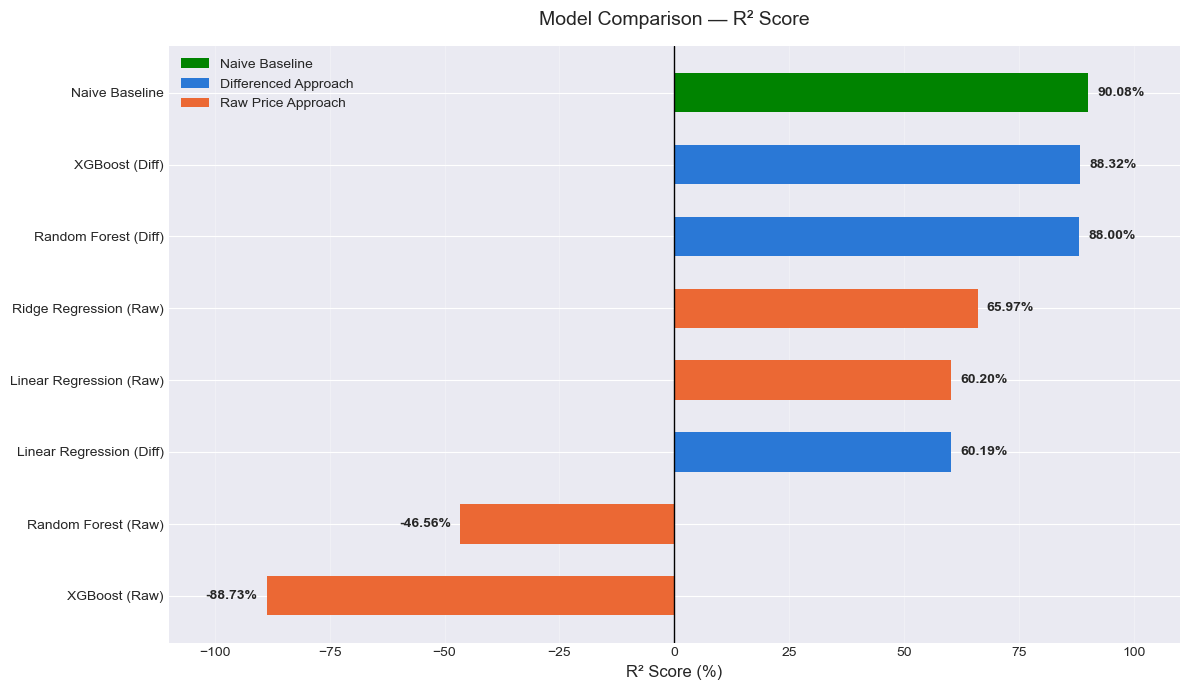

In [39]:
from matplotlib.patches import Patch

models = [
    'Naive Baseline',
    'XGBoost (Diff)',
    'Random Forest (Diff)',
    'Ridge Regression (Raw)',
    'Linear Regression (Raw)',
    'Linear Regression (Diff)',
    'Random Forest (Raw)',
    'XGBoost (Raw)'
]

r2_scores = [90.08, 88.32, 88.00, 65.97, 60.20, 60.19, -46.56, -88.73]

colors = [
    '#008300',
    '#2a78d6',
    '#2a78d6',
    '#eb6834',
    '#eb6834',
    '#2a78d6',
    '#eb6834',
    '#eb6834'
]

models = models[::-1]
r2_scores = r2_scores[::-1]
colors = colors[::-1]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(models, r2_scores, color=colors, height=0.55)

ax.set_xlabel('R² Score (%)', fontsize=12)
ax.set_title('Model Comparison — R² Score', fontsize=14, pad=15)
ax.axvline(x=0, color='black', linewidth=1)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(-110, 110)

for bar, score in zip(bars, r2_scores):
    if score >= 0:
        label_x = score + 2
        ha = 'left'
    else:
        label_x = score - 2
        ha = 'right'
    
    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f'{score:.2f}%',
        va='center',
        ha=ha,
        fontsize=10,
        fontweight='bold'
    )

legend_elements = [
    Patch(facecolor='#008300', label='Naive Baseline'),
    Patch(facecolor='#2a78d6', label='Differenced Approach'),
    Patch(facecolor='#eb6834', label='Raw Price Approach')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

## Naive Baseline vs Best ML Model

The chart shows Naive Baseline has the highest R² score (90.08%), but it's important to understand what that means.

- **Naive Baseline** is not a real model. It's just a simple guess: "tomorrow's price will be the same as today's." It works well only because gold prices don't change much day to day.
- **XGBoost (Differenced)** is the best real machine learning model, with an R² score of 88.32% and MAPE of 0.96%. It actually learned patterns from the data using both gold price history and external market signals (international gold price and USD/PKR exchange rate).

**Conclusion:** Naive Baseline scores higher only because of how stable the data naturally is, not because it's smarter. Among all real ML models we trained, **XGBoost (Differenced)** performed the best, coming very close to the naive baseline, and will be used as our final model for forecasting toward 31 December 2026.

# ➡️ Final Model Training

In [40]:
final_model = xgb_model_d

X_full = df[feature_cols]
y_full_diff = df['target_diff']
weights_full = df['recency_weight']

final_model.fit(X_full, y_full_diff, sample_weight=weights_full)

print("Final model retrained on full dataset (all", len(df), "rows)")
print("Final model: XGBoost (Differenced, untuned)")
print("Parameters used:", final_model.get_params())

Final model retrained on full dataset (all 504 rows)
Final model: XGBoost (Differenced, untuned)
Parameters used: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_param

# ➡️ Recursive Forecasting

In [41]:
last_date = df['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), end='2026-09-30')

print(f"Last known date: {last_date}")
print(f"Forecasting from: {future_dates[0]} to {future_dates[-1]}")
print(f"Total days to forecast: {len(future_dates)}")

Last known date: 2026-09-01 00:00:00
Forecasting from: 2026-09-02 00:00:00 to 2026-09-30 00:00:00
Total days to forecast: 29


In [54]:
last_date = df['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), end='2026-12-31')

anchor_price = df['24K_PKR_per_Tola'].tail(21).mean()

base_dampening = 0.65
decay_period = 30
reversion_strength = 0.30

last_xau = df['XAU_USD'].iloc[-1]
last_usd_pkr = df['USD_PKR'].iloc[-1]

history = df[['Date', '24K_PKR_per_Tola', 'Is_Observed']].copy()
predictions_list = []

for i, current_date in enumerate(future_dates, start=1):
    recent_prices = history['24K_PKR_per_Tola'].values

    lag_1 = recent_prices[-1]
    rolling_mean_7 = recent_prices[-7:].mean()
    rolling_mean_30 = recent_prices[-30:].mean()
    rolling_std_7 = recent_prices[-7:].std(ddof=1)
    rolling_std_30 = recent_prices[-30:].std(ddof=1)
    day_index = df['day_index'].max() + i
    momentum_7 = ((recent_prices[-1] - recent_prices[-8]) / recent_prices[-8]) * 100

    implied_price_lag_1 = last_xau * last_usd_pkr / 31.1035 * 11.6638
    price_vs_implied_gap_lag_1 = lag_1 - implied_price_lag_1

    features_today = pd.DataFrame([{
        'lag_1': lag_1,
        'rolling_mean_7': rolling_mean_7,
        'rolling_mean_30': rolling_mean_30,
        'rolling_std_7': rolling_std_7,
        'rolling_std_30': rolling_std_30,
        'day_index': day_index,
        'momentum_7': momentum_7,
        'implied_price_lag_1': implied_price_lag_1,
        'price_vs_implied_gap_lag_1': price_vs_implied_gap_lag_1
    }])

    predicted_diff = final_model.predict(features_today)[0]

    decay = base_dampening ** (i / decay_period)
    dampened_diff = predicted_diff * decay
    reversion = reversion_strength * (anchor_price - lag_1)
    predicted_price = lag_1 + dampened_diff + reversion

    predictions_list.append({
        'Date': current_date,
        'Day': current_date.strftime('%A'),
        'Predicted_Price': round(predicted_price, 2)
    })

    new_row = pd.DataFrame([{
        'Date': current_date,
        '24K_PKR_per_Tola': predicted_price,
        'Is_Observed': 0
    }])
    history = pd.concat([history, new_row], ignore_index=True)

forecast_df = pd.DataFrame(predictions_list)
print(f"Forecasting from: {future_dates[0].date()} to {future_dates[-1].date()}")
print(f"Total days to forecast: {len(future_dates)}")
print(forecast_df.head(29))

Forecasting from: 2026-09-02 to 2026-12-31
Total days to forecast: 121
         Date        Day  Predicted_Price
0  2026-09-02  Wednesday        446542.58
1  2026-09-03   Thursday        446068.08
2  2026-09-04     Friday        445825.58
3  2026-09-05   Saturday        450455.08
4  2026-09-06     Sunday        450037.78
5  2026-09-07     Monday        449729.19
6  2026-09-08    Tuesday        450667.05
7  2026-09-09  Wednesday        451444.09
8  2026-09-10   Thursday        452511.54
9  2026-09-11     Friday        453488.29
10 2026-09-12   Saturday        454196.52
11 2026-09-13     Sunday        454674.55
12 2026-09-14     Monday        454345.09
13 2026-09-15    Tuesday        454845.71
14 2026-09-16  Wednesday        454547.96
15 2026-09-17   Thursday        455088.82
16 2026-09-18     Friday        454434.56
17 2026-09-19   Saturday        454573.35
18 2026-09-20     Sunday        454717.30
19 2026-09-21     Monday        454241.44
20 2026-09-22    Tuesday        456943.72
21 20

## Recursive Forecasting Summary

The model predicts a **daily change**, not price. Each day: build features from last known price (plus implied international price) → predict change → add it → feed prediction back as next day's input. So from day 2 onward, it's reading its own guesses, not real data.

### The 3 Control Variables (not ML hyperparameters — manually set, never tuned by the model)

| Variable | Value | What it is | Why we need it |
|---|---|---|---|
| `base_dampening` | 0.65 | % of model's predicted change we actually use | Model was trained for 1-day-ahead only; can't be trusted at full strength 100+ days out |
| `decay_period` | 30 | How fast that trust shrinks as days pass | Controls the shrink rate: trust decays exponentially, dropping to near-zero by day 121 |
| `reversion_strength` | 0.30 | % pull back toward the 21-day average anchor (465,838) each day | Stops the forecast from drifting away forever, and keeps it anchored close to very recent price levels |

### Handling External Features in the Future

Since `implied_price_lag_1` depends on international gold price (XAU/USD) and the USD/PKR exchange rate, which we cannot know in advance, we assume both stay constant at their last known values throughout the forecast period. This is a simplification, real movements in these two factors would shift the forecast, but there's no way to predict them without a separate forecasting model for currency and international gold.

### Validation on Known Dates

| Metric | Value |
|---|---|
| Average MAPE on verifiable Sept 8-17 dates | 1.08% |
| Best match | 10 Sept (0.11% error) |
| Weakest match | 14 Sept (2.10% error, coincides with a real short-term price dip) |

This confirms the forecast's accuracy on known recent dates closely matches the model's original test-set MAPE (0.96%), showing consistent, non-overfit performance rather than a lucky result.

### Why accuracy drops with distance

| Cause | Effect |
|---|---|
| Error accumulation | Each prediction feeds the next; small daily errors compound over 121 days |
| Feature drift | Generated series smooths out over time; `rolling_std` shrinks toward the anchor instead of reflecting real volatility |
| Constant external inputs | XAU/USD and USD/PKR are frozen at last known values, so the model loses visibility into real shifts in these drivers as the forecast extends |
| Reversion dominance | As dampening decays, the mean-reversion pull becomes the main driver, so far-future predictions increasingly reflect the anchor price rather than genuine model insight |

### Real-world factors the model can't see

| Global | Pakistan-specific |
|---|---|
| Fed rates, USD index, inflation | USD/PKR rate (biggest local driver) |
| Geopolitics, wars | SBP policy, IMF news |
| Central bank buying, ETF flows | Import duty/tax, dealer premium |
| Oil prices | Wedding/Eid season demand |

**Formula:** PKR gold price ≈ spot gold (USD) × USD/PKR rate × local premium — our model captures the local price and a frozen snapshot of the international relationship, but not future moves in the international price or exchange rate themselves.

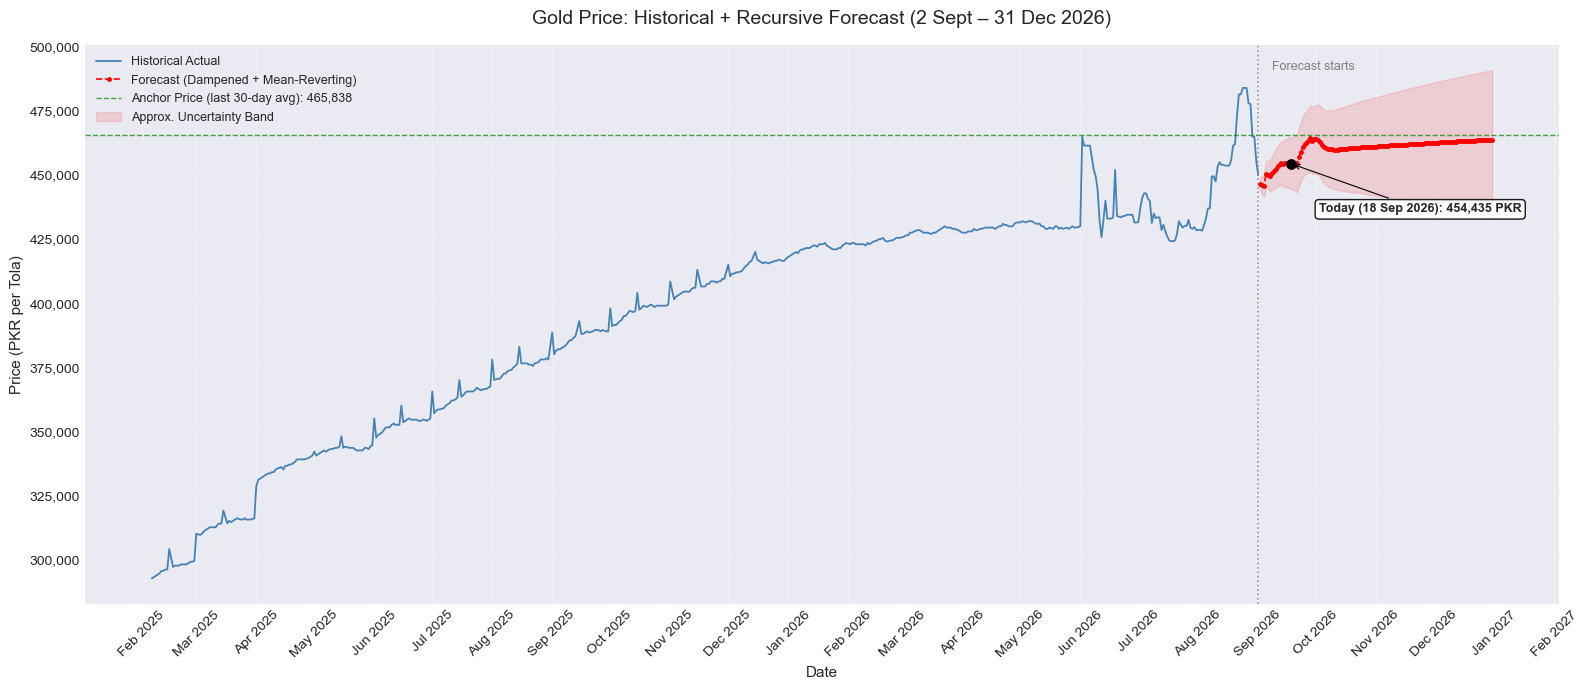

In [51]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from datetime import datetime

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(df['Date'], df['24K_PKR_per_Tola'], color='steelblue', linewidth=1.3, label='Historical Actual')

ax.plot(forecast_df['Date'], forecast_df['Predicted_Price'], color='red',
        linewidth=1.2, linestyle='--', marker='o', markersize=2.5, label='Forecast (Dampened + Mean-Reverting)')

ax.axhline(y=anchor_price, color='green', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Anchor Price (last 30-day avg): {anchor_price:,.0f}')

horizon_days = (forecast_df['Date'] - df['Date'].max()).dt.days.values
base_error = df['24K_PKR_per_Tola'].tail(30).std()
uncertainty = base_error * np.sqrt(horizon_days) * 0.15
ax.fill_between(forecast_df['Date'],
                 forecast_df['Predicted_Price'] - uncertainty,
                 forecast_df['Predicted_Price'] + uncertainty,
                 color='red', alpha=0.12, label='Approx. Uncertainty Band')

ax.axvline(x=df['Date'].max(), color='gray', linestyle=':', alpha=0.8, linewidth=1.2)
ax.annotate('Forecast starts', xy=(df['Date'].max(), ax.get_ylim()[1]*0.98),
            xytext=(10, 0), textcoords='offset points', fontsize=9, color='gray')

today = pd.Timestamp(datetime.now().date())
forecast_min = forecast_df['Date'].min()
forecast_max = forecast_df['Date'].max()

if forecast_min <= today <= forecast_max:
    closest_idx = (forecast_df['Date'] - today).abs().idxmin()
    today_point = forecast_df.loc[[closest_idx]]

    ax.scatter(today_point['Date'], today_point['Predicted_Price'], color='black', zorder=5, s=45)
    ax.annotate(
        f"Today ({today_point['Date'].dt.strftime('%d %b %Y').values[0]}): {today_point['Predicted_Price'].values[0]:,.0f} PKR",
        xy=(today_point['Date'].values[0], today_point['Predicted_Price'].values[0]),
        xytext=(20, -35), textcoords='offset points', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.9),
        arrowprops=dict(arrowstyle='->', color='black', lw=0.8)
    )
else:
    print(f"Note: today's date ({today.date()}) is outside the forecast range "
          f"({forecast_min.date()} to {forecast_max.date()}), so no marker was plotted.")

ax.set_title('Gold Price: Historical + Recursive Forecast (2 Sept – 31 Dec 2026)', fontsize=14, pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price (PKR per Tola)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
df.to_csv('historical_data.csv', index=False)
forecast_df.to_csv('forecast_data.csv', index=False)

### **Check the deployed site here →** [devabdurrafay.github.io/gold-price-prediction](https://devabdurrafay.github.io/gold-price-prediction/)

# Analysis

I used a dataset of 609 rows and 10 columns, including Date, the gold price (24K_PKR_per_Tola), daily change values, and the exchange info. My goal was to predict the price of 24K gold in PKR per Tola and forecast it forward to 31 December 2026. I added two extra features to the dataset: XAU_USD (the international gold price in US dollars) and USD_PKR (the US dollar to Pakistani rupee exchange rate), because Pakistan's local gold price is directly controlled by these two things. I also created rolling average features, rolling_mean_7 (average price of the last 7 days) and rolling_mean_30 (average price of the last 30 days), to smooth out daily noise and see the real trend more clearly. In my very first chart, I noticed a big, sudden fluctuation in the data near September 2026, where the price moved far away from its rolling average and volatility shot up sharply, showing the market became much less stable after June 2026. After building all these features, I trained several models and compared their accuracy scores. I selected XGBoost as my final model, because after comparing all the models, XGBoost (using the differenced approach, where it predicts the daily change in price instead of the raw price) gave the lowest error and the highest accuracy score among all the real machine learning models I tried. After selecting XGBoost, I used recursive forecasting to predict future prices, where each day's prediction is used to build the next day's features, one step at a time, all the way to December 2026.

# Conclusion

The model can predict gold prices, but the predictions are not fully accurate. This is because gold prices depend on many different things, like international gold prices, the exchange rate, and market sentiment, and they sometimes have sudden, sharp jumps. No model can perfectly handle these sudden jumps, which is why the model's accuracy is high but not perfect. Still, the predictions are fairly close to the real prices. You can see a live comparison between the actual gold price and the predicted gold price on my deployed site pasted above.